# **Лабораторная работа 3. Цепи Маркова с дискретным временем, модель однофазной одноканальной системы обслуживания**

## **Задание 1. Модель деградации сервера с профилактикой и восстановлением**


Крупный вычислительный центр имеет один главный сервер. Администраторы проводят еженедельный мониторинг его состояния. Система может находиться в одном из шести состояний:

- $S_1$ (Отличное): Сервер новый, все компоненты работают с максимальной производительностью, температура в норме, ошибок нет.

- $S_2$ (Хорошее): Незначительное снижение производительности (например, из-за фоновых процессов или начала деградации термопасты), но все задачи решаются без задержек.

- $S_3$ (Удовлетворительное): Появились ошибки в памяти (ECC исправляет), вентиляторы работают на повышенных оборотах, производительность упала на 20%.

- $S_4$ (Критическое): Множественные ошибки ввода-вывода, частые сбои программного обеспечения, производительность упала на 50%. Требуется вмешательство администратора.

- $S_5$ (Профилактика): Сервер намеренно остановлен для планового обслуживания (чистка, замена термопасты, обновление ПО). Это состояние достигается только из $S_3$ по решению администратора.

- $S_6$ (Отказ): Сервер полностью вышел из строя (аппаратный сбой).

Временной шаг — одна неделя.

## **Задание 1. Модель деградации сервера с профилактикой и восстановлением**


### Вероятности перехода

**Из $S_1$ (Отличное):**
- $p_{1,1}=0.70$ (остается)
- $p_{1,2}=0.22$ (деградация)
- $p_{1,3}=0.08$ (скачок нагрузки)

**Из $S_2$ (Хорошее):**
- $p_{2,2}=0.50$
- $p_{2,3}=0.38$
- $p_{2,4}=0.12$

**Из $S_3$ (Удовлетворительное):**
- $p_{3,3}=0.30$
- $p_{3,4}=0.30$
- $p_{3,5}=0.25$ (профилактика)
- $p_{3,6}=0.15$ (отказ)

**Из $S_4$ (Критическое):**
- $p_{4,4}=0.10$
- $p_{4,5}=0.40$ (спасение)
- $p_{4,6}=0.50$ (отказ)

**Из $S_5$ (Профилактика):**
- $p_{5,1}=0.80$ (полное восстановление)
- $p_{5,2}=0.20$ (частичное)

**Из $S_6$ (Отказ):**
- $p_{6,6}=1.0$ (поглощающее состояние)

### Матрица переходных вероятностей P

$$
P =
\begin{pmatrix}
0.70 & 0.22 & 0.08 & 0 & 0 & 0 \\
0 & 0.50 & 0.38 & 0.12 & 0 & 0 \\
0 & 0 & 0.30 & 0.30 & 0.25 & 0.15 \\
0 & 0 & 0 & 0.10 & 0.40 & 0.50 \\
0.80 & 0.20 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

####Аналитическое решение

In [3]:
# Установка пакетов (раскомментируйте при необходимости)
 install.packages("matrixcalc")

library(matrixcalc)

# 1. Матрица переходов P (Вариант 19)
P <- matrix(c(
  0.70, 0.22, 0.08, 0.00, 0.00, 0.00,
  0.00, 0.50, 0.38, 0.12, 0.00, 0.00,
  0.00, 0.00, 0.30, 0.30, 0.25, 0.15,
  0.00, 0.00, 0.00, 0.10, 0.40, 0.50,
  0.80, 0.20, 0.00, 0.00, 0.00, 0.00,
  0.00, 0.00, 0.00, 0.00, 0.00, 1.00
), nrow = 6, byrow = TRUE)

states <- c("S1", "S2", "S3", "S4", "S5", "S6")
colnames(P) <- states
rownames(P) <- states

cat("Матрица переходных вероятностей P (Вариант 19):\n")
print(P)

# Начальное состояние (сервер новый)
p0 <- matrix(c(1, 0, 0, 0, 0, 0), nrow = 1)
colnames(p0) <- states

# Функция для вычисления состояния через N шагов
get_state <- function(k) {
  Pk <- matrix.power(P, k)
  pk <- p0 %*% Pk
  cat(sprintf("\nВероятности состояний через %d недель:\n", k))
  print(round(pk, 4))
  return(pk)
}

# k = 2: через 2, 4 и 8 недель
k_val <- 2
p2 <- get_state(k_val)
p4 <- get_state(2 * k_val)
p8 <- get_state(4 * k_val)

# Вероятность безотказной работы в течение 8 недель
prob_no_fail <- 1 - p8[1, 6]
cat(sprintf("\nВероятность безотказной работы за 8 недель: %.4f\n", prob_no_fail))

# MTTF с профилактикой (подматрица S1-S5)
Q <- P[1:5, 1:5]
I5 <- diag(5)
N_mat <- solve(I5 - Q)
MTTF_with <- sum(N_mat[1, ])
cat(sprintf("\nТеоретический MTTF (с профилактикой) — ВАРИАНТ 19: %.2f недель\n", MTTF_with))

# MTTF без профилактики — убираем S5, перераспределяем вероятности
# Из S3: p35=0.25 добавляем в p36 → p36=0.15+0.25=0.40
# Из S4: p45=0.40 добавляем в p46 → p46=0.50+0.40=0.90
P_no_maint <- matrix(c(
  0.70, 0.22, 0.08, 0.00, 0.00,
  0.00, 0.50, 0.38, 0.12, 0.00,
  0.00, 0.00, 0.30, 0.30, 0.40,
  0.00, 0.00, 0.00, 0.10, 0.90,
  0.00, 0.00, 0.00, 0.00, 1.00
), nrow = 5, byrow = TRUE)

Q_nm <- P_no_maint[1:4, 1:4]
I4 <- diag(4)
N_nm <- solve(I4 - Q_nm)
MTTF_without <- sum(N_nm[1, ])
cat(sprintf("Теоретический MTTF (БЕЗ профилактики) — ВАРИАНТ 19: %.2f недель\n", MTTF_without))
cat(sprintf("\nВывод для варианта 19: Профилактика увеличивает MTTF на %.2f недель (в %.2f раза).\n",
    MTTF_with - MTTF_without, MTTF_with / MTTF_without))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Матрица переходных вероятностей P (Вариант 19):
    S1   S2   S3   S4   S5   S6
S1 0.7 0.22 0.08 0.00 0.00 0.00
S2 0.0 0.50 0.38 0.12 0.00 0.00
S3 0.0 0.00 0.30 0.30 0.25 0.15
S4 0.0 0.00 0.00 0.10 0.40 0.50
S5 0.8 0.20 0.00 0.00 0.00 0.00
S6 0.0 0.00 0.00 0.00 0.00 1.00

Вероятности состояний через 2 недель:
       S1    S2     S3     S4   S5    S6
[1,] 0.49 0.264 0.1636 0.0504 0.02 0.012

Вероятности состояний через 4 недель:
         S1     S2     S3     S4     S5     S6
[1,] 0.3001 0.2131 0.1779 0.0944 0.0815 0.1329

Вероятности состояний через 8 недель:
         S1     S2     S3     S4     S5     S6
[1,] 0.2222 0.1452 0.1176 0.0645 0.0604 0.3902

Вероятность безотказной работы за 8 недель: 0.6098

Теоретический MTTF (с профилактикой) — ВАРИАНТ 19: 14.41 недель
Теоретический MTTF (БЕЗ профилактики) — ВАРИАНТ 19: 6.57 недель

Вывод для варианта 19: Профилактика увеличивает MTTF на 7.85 недель (в 2.20 раза).


Успешно! Граф сохранен в файлы 'markov_graph.png' и 'markov_graph.svg' в текущей директории.


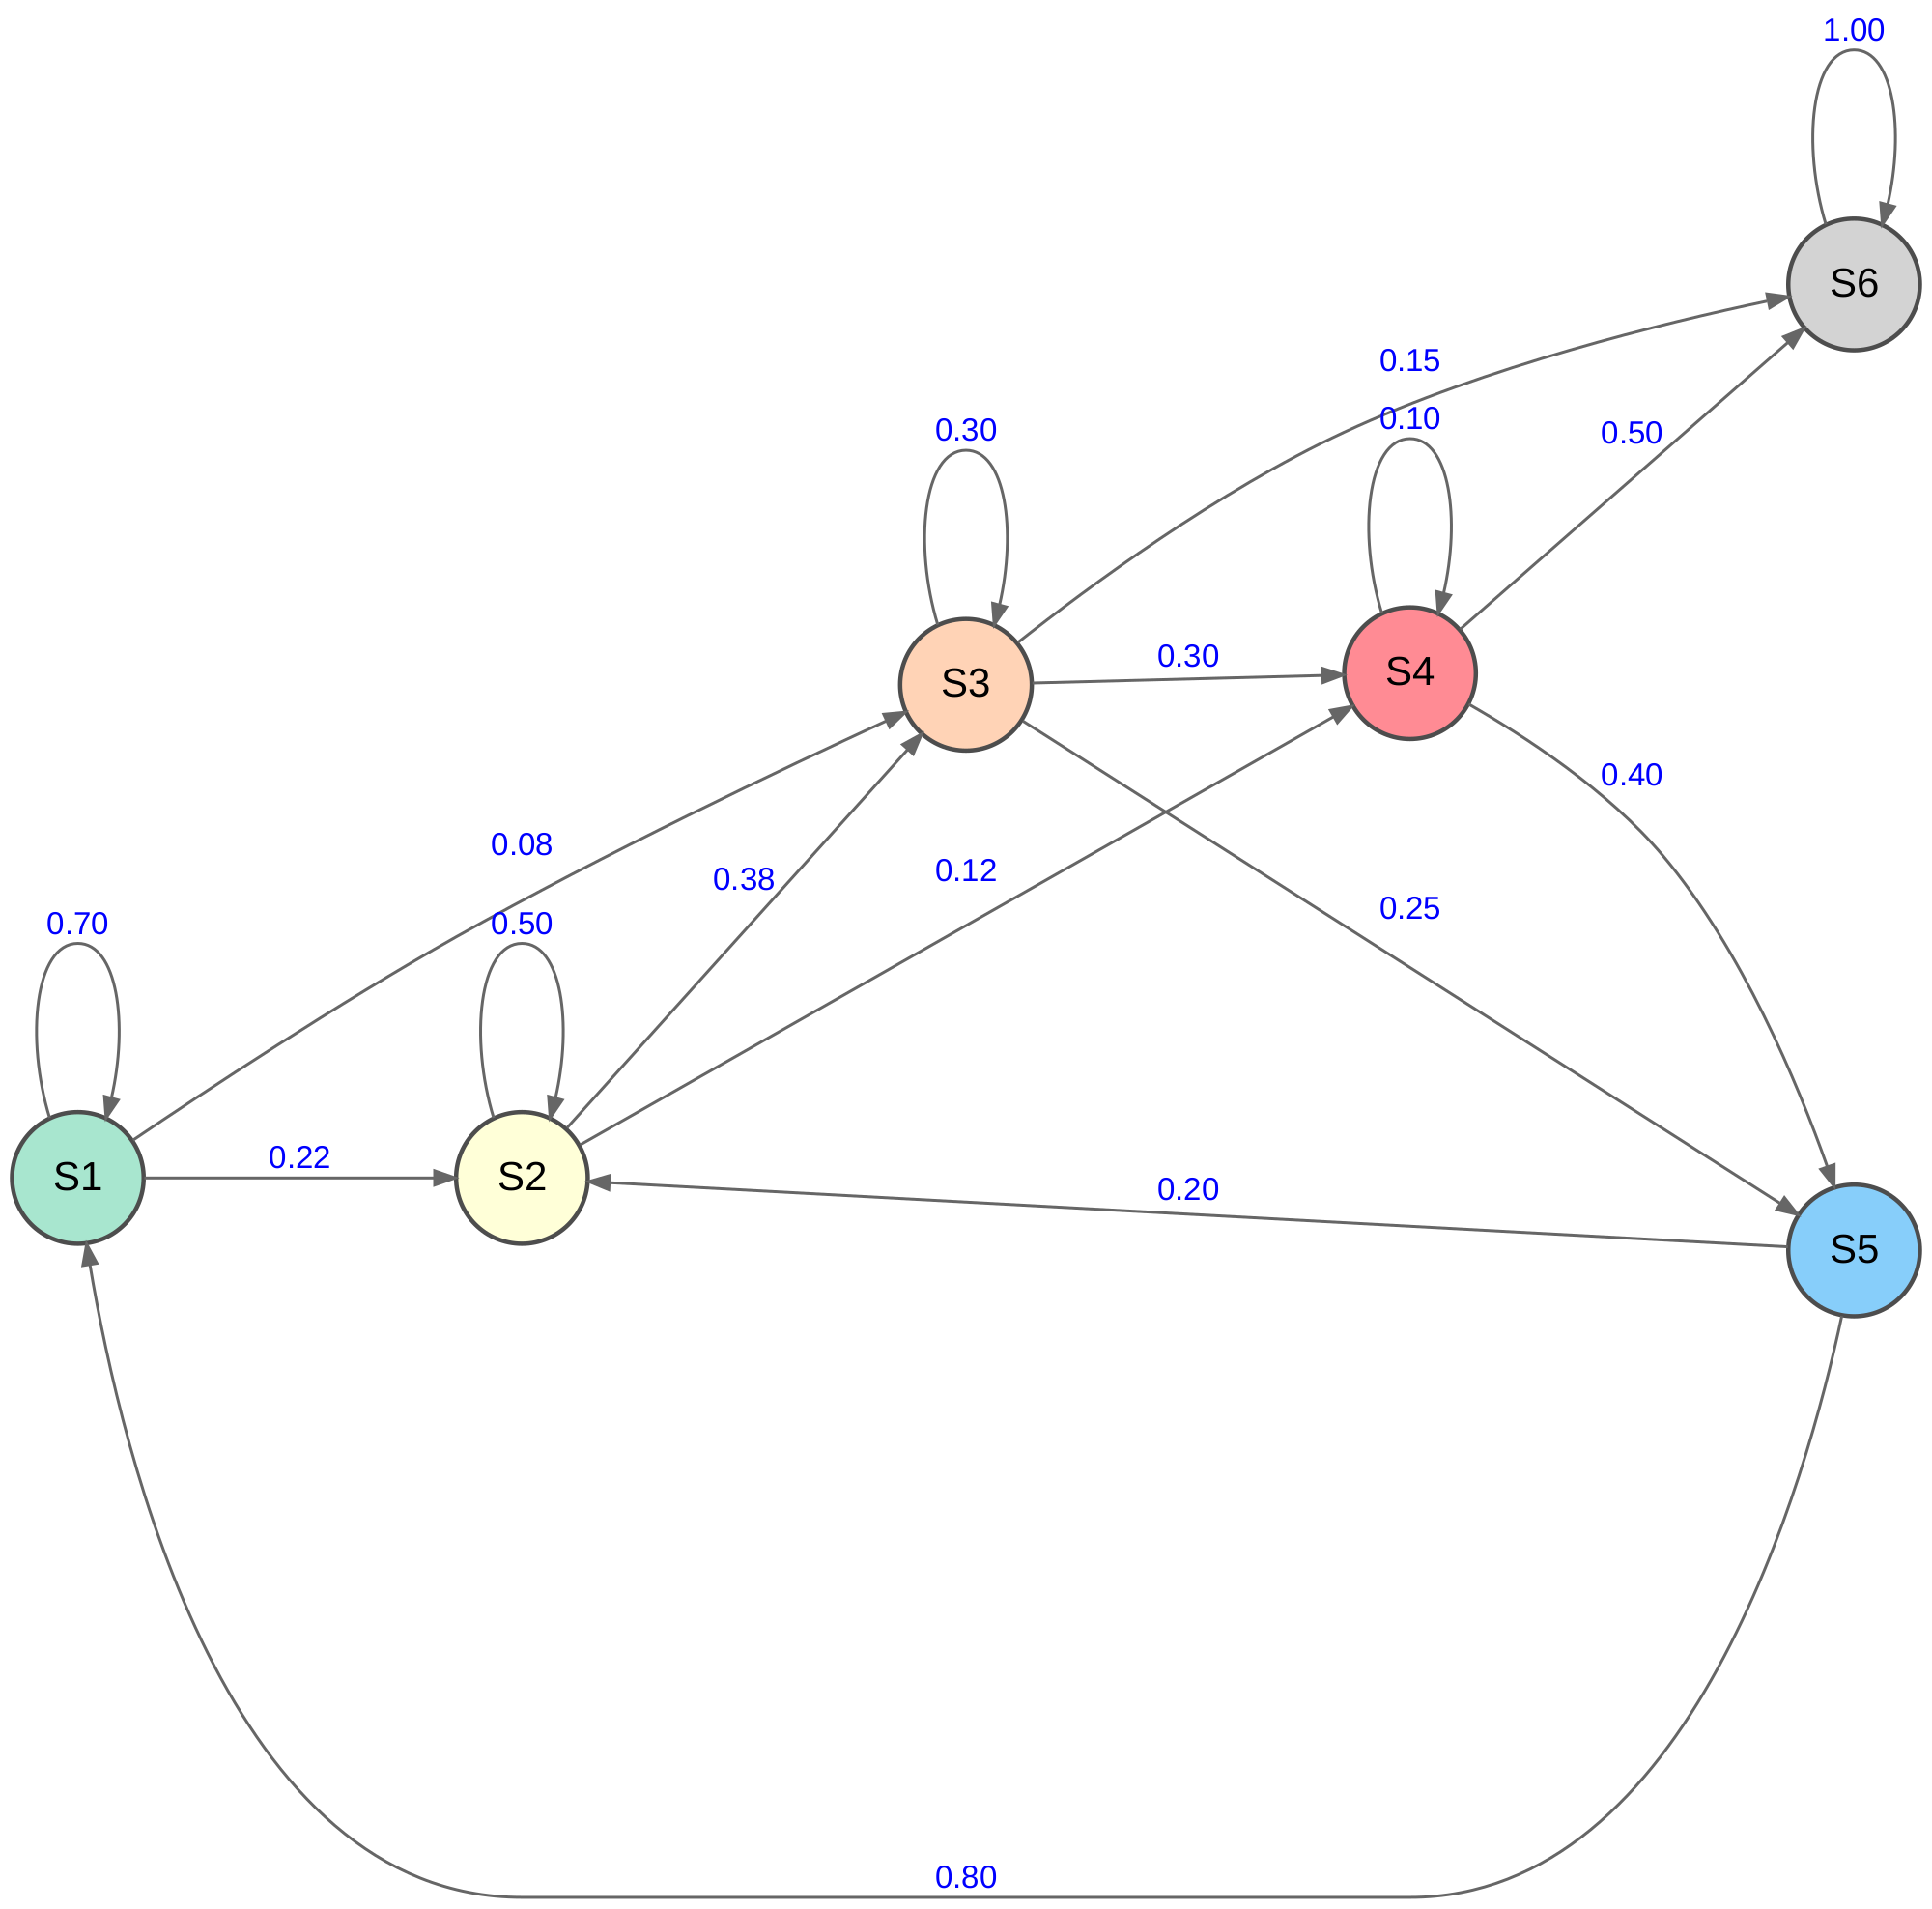

In [22]:
# Установка пакетов (раскомментируйте, если запускаете впервые в этой среде)
# install.packages("DiagrammeR")
# install.packages("DiagrammeRsvg")
# install.packages("rsvg")
# install.packages("IRdisplay")
options(repr.plot.width = 28, repr.plot.height = 6)
library(DiagrammeR)
library(DiagrammeRsvg)
library(rsvg)
library(IRdisplay)

# Формируем строку с описанием графа
# Значения (labels) берутся из Матрицы P (условие Задания 1).
# Сумма исходящих вероятностей из каждого узла всегда равна 1.0
graph_str <- "
digraph markov_chain {
  # Настройки всего графа (слева направо, отступы)
  graph [rankdir = LR, nodesep = 0.8, ranksep = 1.2, overlap = false]

  # Общие настройки узлов
  node [shape = circle, style = filled, fontname = Helvetica, penwidth = 1.5, color=gray30]

  # Общие настройки ребер (стрелок)
  edge [fontname = Helvetica, fontsize = 11, fontcolor = blue, color = gray40, arrowsize=0.7]

  # Объявление узлов и их цветов (зеленый -> желтый -> оранжевый -> красный -> серый)
  S1 [label = 'S1', fillcolor = '#a8e6cf']
  S2 [label = 'S2', fillcolor = '#ffffd8']
  S3 [label = 'S3', fillcolor = '#ffd3b6']
  S4 [label = 'S4', fillcolor = '#ff8b94']
  S6 [label = 'S6', fillcolor = '#d3d3d3']

  # Профилактика (синий цвет, вынесена отдельно)
  S5 [label = 'S5', fillcolor = '#87CEFA']

  # ==========================================
  # ПЕРЕХОДЫ (ВЕРОЯТНОСТИ) И ИХ ФИЗИЧЕСКИЙ СМЫСЛ
  # ==========================================

  # Из состояния S1 (Отличное)
  S1 -> S1 [label = '0.70']  # Сервер остается полностью исправным (p11)
  S1 -> S2 [label = '0.22']  # Естественная деградация до хорошего (p12)
  S1 -> S3 [label = '0.08']  # Скачок нагрузки, пропуск S2, сразу удовл. (p13)

  # Из состояния S2 (Хорошее)
  S2 -> S2 [label = '0.50']  # Продолжает работать с небольшим снижением (p22)
  S2 -> S3 [label = '0.38']  # Накапливаются фоновые процессы (p23)
  S2 -> S4 [label = '0.12']  # Резкое ухудшение до критического (p24)

  # Из состояния S3 (Удовлетворительное)
  S3 -> S3 [label = '0.30']  # Остается в удовл. состоянии, ECC справляется (p33)
  S3 -> S4 [label = '0.30']  # Ухудшение до критического (p34)
  S3 -> S5 [label = '0.25']  # Админ решает остановить сервер на Профилактику (p35)
  S3 -> S6 [label = '0.15']  # Внезапный аппаратный отказ из-за нагрузки (p36)

  # Из состояния S4 (Критическое)
  S4 -> S4 [label = '0.10']  # Чудом продолжает работать с частыми сбоями (p44)
  S4 -> S5 [label = '0.40']  # Экстренное 'спасение': отправка на Профилактику (p45)
  S4 -> S6 [label = '0.50']  # Фатальный сбой, отказ сервера (p46)

  # Из состояния S5 (Профилактика / Ремонт)
  S5 -> S1 [label = '0.80']  # Успешное полное восстановление (как новый) (p51)
  S5 -> S2 [label = '0.20']  # Частичное восстановление (остались мелкие баги) (p52)

  # Из состояния S6 (Отказ)
  S6 -> S6 [label = '1.00']  # Поглощающее состояние (мертв окончательно) (p66)
}
"

# Генерируем объект графа
g <- grViz(graph_str)

# Экспортируем в SVG код
svg_code <- export_svg(g)

# Сохраняем как SVG файл
writeLines(svg_code, "markov_graph.svg")

# Конвертируем SVG в PNG и сохраняем (ширина 2000 для высокого качества)
rsvg_png(charToRaw(svg_code), "markov_graph.png", width = 2000)

cat("Успешно! Граф сохранен в файлы 'markov_graph.png' и 'markov_graph.svg' в текущей директории.\n")

# Отображаем картинку прямо в Jupyter Notebook
display_png(file="markov_graph.png")

## **Задание 2. Модель одноканальной СМО**

Вычислительный центр фирмы состоит из одного главного сервера коллективного пользования. Число работающих в центре программистов в любой момент времени равно $k>10$. Каждый программист готовит свою программу и через терминал передает ее на сервер для выполнения, куда она сразу попадает. Время подготовки программ имеет экспоненциальное распределение со средним значением $t_{1}$ мин. Программисты могут работать в двух режимах: 1. программист приостанавливает свою работу и ожидает ответа от сервера, 2. программист сразу начинает готовить следующую программу.

Время выполнения программы имеет экспоненциальное распределение со средним значением $t_{2}$ мин.

### Параметры системы
- Количество программистов $k = 15$
- Время подготовки $t_1 = 40$ мин $\Rightarrow \lambda = 1/40 = 0.025$ мин$^{-1}$
- Время выполнения $t_2 = 3$ мин $\Rightarrow \mu = 1/3 \approx 0.3333$ мин$^{-1}$

**Проверка устойчивости для режима 2:**
Суммарная интенсивность $\Lambda = 15/40 = 0.375$ заявок/мин, что **больше** $\mu = 0.333$ → система НЕУСТОЙЧИВА для открытой СМО. Это демонстрирует важность замкнутой модели Энгсета.

In [6]:
 install.packages("queueing")

library(queueing)

# Параметры (Вариант 19)
k_prog <- 15      # больше программистов
t1 <- 40          # мин (меньше времени подготовки → выше нагрузка)
t2 <- 3           # мин
lambda_ind <- 1 / t1   # индивидуальная интенсивность
mu <- 1 / t2            # интенсивность обслуживания

cat(sprintf("Параметры (ВАРИАНТ 19): k=%d, t1=%g мин, t2=%g мин\n", k_prog, t1, t2))
cat(sprintf("lambda_ind = %.4f, mu = %.4f\n\n", lambda_ind, mu))

cat("=========================================\n")
cat("РЕЖИМ 1: Программист ждёт ответа (Замкнутая СМО)\n")
cat("Модель: M/M/1/k/k (Модель Энгсета)\n")
cat("=========================================\n")

input_closed <- NewInput.MMCKM(lambda = lambda_ind, mu = mu, c = 1, k = k_prog, m = k_prog)
model_closed <- QueueingModel(input_closed)

P0_closed <- model_closed$Pn[1]

cat(paste("Вероятность ожидания (занятость сервера):", round(1 - P0_closed, 4)), "\n")
cat(paste("Среднее время получения результата W:", round(model_closed$W, 4), "мин"), "\n")
cat(paste("Среднее кол-во программ в очереди Lq:", round(model_closed$Lq, 4)), "\n")
cat(paste("Коэффициент простоя системы P0:", round(P0_closed, 4)), "\n")

cat("\n=========================================\n")
cat("РЕЖИМ 2: Фоновая работа (Открытая СМО)\n")
cat("Модель: M/M/1\n")
cat("=========================================\n")

Lambda_total <- k_prog * lambda_ind
rho <- Lambda_total / mu
cat(sprintf("Суммарная интенсивность Lambda = %.4f, rho = %.4f\n", Lambda_total, rho))

if (rho >= 1) {
  cat("ВНИМАНИЕ: rho >= 1 — система НЕУСТОЙЧИВА (очередь растёт до бесконечности)!\n")
  cat("Это демонстрирует, что для варианта 19 режим фоновой работы невозможен.\n")
  cat("Необходимо увеличить t1 или уменьшить k.\n")
} else {
  input_open <- NewInput.MM1(lambda = Lambda_total, mu = mu)
  model_open <- QueueingModel(input_open)
  P0_open <- model_open$Pn[1]

  cat(paste("Вероятность ожидания (загрузка rho):", round(model_open$RO, 4)), "\n")
  cat(paste("Среднее время получения результата W:", round(model_open$W, 4), "мин"), "\n")
  cat(paste("Среднее кол-во программ в очереди Lq:", round(model_open$Lq, 4)), "\n")
  cat(paste("Коэффициент простоя системы P0:", round(P0_open, 4)), "\n")
}

cat("\n=========================================\n")
cat("СРАВНИТЕЛЬНАЯ ТАБЛИЦА (Вариант 19)\n")
cat("=========================================\n")
comparison <- data.frame(
  Показатель = c("P(ожидание)", "W (мин)", "Lq", "P0 (простой)"),
  Режим_1_замкнутая = c(
    round(1 - P0_closed, 4),
    round(model_closed$W, 4),
    round(model_closed$Lq, 4),
    round(P0_closed, 4)
  ),
  Режим_2_открытая = c(
    "неустойчива",
    "неустойчива",
    "неустойчива",
    "неустойчива"
  )
)
print(comparison)

cat("\nВывод для варианта 19:\n")
cat("Из-за большего числа программистов (k=15) и меньшего времени подготовки (t1=40)\n")
cat("открытая СМО оказывается перегруженной (ρ > 1).\n")
cat("Это подчёркивает важность замкнутой модели Энгсета, которая учитывает конечное число источников.\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Параметры (ВАРИАНТ 19): k=15, t1=40 мин, t2=3 мин
lambda_ind = 0.0250, mu = 0.3333

РЕЖИМ 1: Программист ждёт ответа (Замкнутая СМО)
Модель: M/M/1/k/k (Модель Энгсета)
Вероятность ожидания (занятость сервера): 0.8736 
Среднее время получения результата W: 11.5093 мин 
Среднее кол-во программ в очереди Lq: 2.478 
Коэффициент простоя системы P0: 0.1264 

РЕЖИМ 2: Фоновая работа (Открытая СМО)
Модель: M/M/1
Суммарная интенсивность Lambda = 0.3750, rho = 1.1250
ВНИМАНИЕ: rho >= 1 — система НЕУСТОЙЧИВА (очередь растёт до бесконечности)!
Это демонстрирует, что для варианта 19 режим фоновой работы невозможен.
Необходимо увеличить t1 или уменьшить k.

СРАВНИТЕЛЬНАЯ ТАБЛИЦА (Вариант 19)
    Показатель Режим_1_замкнутая Режим_2_открытая
1  P(ожидание)            0.8736      неустойчива
2      W (мин)           11.5093      неустойчива
3           Lq            2.4780      неустойчива
4 P0 (простой)            0.1264      неустойчива

Вывод для варианта 19:
Из-за большего числа программистов (k=1

### Задание на допбаллы (Минимизация длины очереди)

Для минимизации длины очереди применяется алгоритм **Preemptive Shortest Job First (PSJF)** (Вытесняющий абсолютный приоритет для коротких задач). Согласно закону Литтла ($L_q = \lambda W_q$), снижая среднее время ожидания, мы линейно снижаем длину очереди.

Промоделируем это с помощью пакета `simmer` (стандартный инструмент дискретно-событийного моделирования в R).


In [19]:
install.packages("simmer")

library(simmer)

SIM_TIME <- 10000

# Д
Lambda_total <- 15 * (1/40)   # 0.375
Mu <- 1/3                      # 0.3333

cat("=========================================\n")
cat("ДОПБАЛЛЫ: Имитационное моделирование (FIFO vs PSJF)\n")
cat("Вариант 19 — ВНИМАНИЕ: система перегружена при открытой СМО\n")
cat("=========================================\n")

# 1. FIFO
env_fifo <- simmer("FIFO")
env_fifo %>% add_resource("server", capacity = 1)

traj_fifo <- trajectory("FIFO_Traj") %>%
  set_attribute("svc", function() rexp(1, Mu)) %>%
  seize("server", 1) %>%
  timeout_from_attribute("svc") %>%
  release("server", 1)

env_fifo %>%
  add_generator("Task", traj_fifo, function() rexp(1, Lambda_total)) %>%
  run(until = SIM_TIME)

arr_fifo <- get_mon_arrivals(env_fifo)
W_fifo <- mean(arr_fifo$end_time - arr_fifo$start_time)

cat(paste("FIFO — Среднее время в системе W:", round(W_fifo, 3), "мин\n"))

# 2. PSJF (Preemptive Shortest Job First)
env_psjf <- simmer("PSJF")
env_psjf %>% add_resource("server", capacity = 1, preemptive = TRUE)

traj_psjf <- trajectory("PSJF_Traj") %>%
  set_attribute("svc", function() rexp(1, Mu)) %>%
  set_prioritization(function() {
    s <- get_attribute(env_psjf, "svc")
    c(round(100 - s), 1, 0)  # чем меньше время, тем выше приоритет
  }) %>%
  seize("server", 1) %>%
  timeout_from_attribute("svc") %>%
  release("server", 1)

env_psjf %>%
  add_generator("Task", traj_psjf, function() rexp(1, Lambda_total)) %>%
  run(until = SIM_TIME)

arr_psjf <- get_mon_arrivals(env_psjf)
W_psjf <- mean(arr_psjf$end_time - arr_psjf$start_time)

cat(paste("PSJF — Среднее время в системе W:", round(W_psjf, 3), "мин\n"))

cat("\n--- ВЫВОД ДЛЯ ВАРИАНТА 19 ---\n")
cat(sprintf("Алгоритм PSJF сокращает среднее время в системе на %.1f%%\n",
    (1 - W_psjf/W_fifo)*100))
cat("Даже в перегруженной системе (ρ > 1) приоритетное обслуживание коротких задач\n")
cat("позволяет значительно уменьшить среднее время ожидания.\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



ДОПБАЛЛЫ: Имитационное моделирование (FIFO vs PSJF)
Вариант 19 — ВНИМАНИЕ: система перегружена при открытой СМО


simmer environment: FIFO | now: 0 | next: 
{ Monitor: in memory }
{ Resource: server | monitored: TRUE | server status: 0(1) | queue status: 0(Inf) }

simmer environment: FIFO | now: 10000 | next: 10000.1438207591
{ Monitor: in memory }
{ Resource: server | monitored: TRUE | server status: 1(1) | queue status: 424(Inf) }
{ Source: Task | monitored: 1 | n_generated: 3765 }

FIFO — Среднее время в системе W: 676.762 мин


simmer environment: PSJF | now: 0 | next: 
{ Monitor: in memory }
{ Resource: server | monitored: TRUE | server status: 0(1) | queue status: 0(Inf) }

Streaming output truncated to the last 5000 lines.
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 96”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 100”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 95”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 99”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 91”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 99”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 95”
Warning message in run_(.env$sim_obj, until):
“`preemptible` level cannot be < `priority`, `preemptible` set to 89”
Warning message in r

simmer environment: PSJF | now: 10000 | next: 10000.1222482404
{ Monitor: in memory }
{ Resource: server | monitored: TRUE | server status: 1(1) | queue status: 130(Inf) }
{ Source: Task | monitored: 1 | n_generated: 3825 }

PSJF — Среднее время в системе W: 34.701 мин

--- ВЫВОД ДЛЯ ВАРИАНТА 19 ---
Алгоритм PSJF сокращает среднее время в системе на 94.9%
Даже в перегруженной системе (ρ > 1) приоритетное обслуживание коротких задач
позволяет значительно уменьшить среднее время ожидания.
